# Assignment 3 — IMDB Sentiment & Regularisation

**DATAX504** · Due end of Week 6

Build on **Chapter 5** (regularisation / early stopping) and **Chapter 7** (Keras `compile` / `fit`, callbacks, saving). A compact Sequential stack is fine; you may use the **Functional API** if you prefer (same depth of learning either way).

## Tasks
1. Load IMDB, pad sequences, create a train / validation split
2. Train a **baseline** sentiment model and record best validation accuracy
3. Produce a **diagram** of your model architecture (see §2b)
4. Apply **two** of: L2, dropout, early stopping — report best val accuracy and name the techniques
5. Learning-rate schedule experiment (`ReduceLROnPlateau` or `LearningRateScheduler`)
6. Save the model you consider best with `model.save(...)` and check that it reloads
7. ~200-word reflection on what you learned

## Moodle fields
`a3_repo`, `a3_baseline_val`, `a3_best_val`, `a3_techniques`, `a3_model_file`

## AI disclosure (required)
Fill the table in the next cell before you submit.

## AI disclosure

| Field | Your answer                                                                                                                                                                                                                                          |
|-------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Tool / model | OpenCode Zen + Big Pickle + Codex5.5                                                                                                                                                                                                                 |
| Used for | Explaining the assignment notebook, interpreting the model architecture diagram, explaining the learning-rate schedule section, comparing validation accuracy results, helping choose the best model    |
| Verified how | All explanations and suggestions were manually checked against my notebook outputs and assignment requirements. I re-ran the models, compared the validation accuracies, saved and reloaded the selected best model, and confirmed its test accuracy. |
| Not used for | Automatically completing the whole assignment, generating all code without my input, or submitting results without manual testing and verification.                                                                                                  |

In [12]:
from os.path import split

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers, regularizers, callbacks

# Optional for plot_model (Ch 7). If import fails, use model.summary() + a drawn sketch (see §2b).
try:
    from keras.utils import plot_model
except ImportError:
    plot_model = None
from IPython.display import Image, display
keras.utils.set_random_seed(42)

## 1. Load & prepare IMDB

Hints (fill in the blanks):
- `keras.datasets.imdb.load_data(num_words=...)`
- pad both train and test with `keras.utils.pad_sequences(..., maxlen=...)`
- hold out the **first 10_000** padded training examples as validation (Ch 4 / 5 style split)
- keep the rest of the training set for fitting

In [13]:
max_features = 10000
max_len = 500

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

# TODO: pad sequences so every review has length max_len
x_train = keras.utils.pad_sequences(x_train,maxlen = max_len)  # pad_sequences(...)
x_test = keras.utils.pad_sequences(x_test,maxlen = max_len)

# TODO: validation split — first 10_000 samples for val, remainder for train
x_val = x_train[:10000]
y_val = y_train[:10000]
x_train = x_train[10000:]
y_train = y_train[10000:]

print("train:", getattr(x_train, "shape", None), getattr(y_train, "shape", None))
print("val:  ", getattr(x_val, "shape", None), getattr(y_val, "shape", None))
print("test: ", getattr(x_test, "shape", None), getattr(y_test, "shape", None))

train: (15000, 500) (15000,)
val:   (10000, 500) (10000,)
test:  (25000, 500) (25000,)


## 2. Baseline model

Suggested architecture (you may change widths if you document why):
1. `Embedding(max_features, 32, input_length=max_len)` — turns token ids into vectors
2. `GlobalAveragePooling1D()` — mean over the time axis
3. `Dense(32, activation="relu")`
4. `Dense(1, activation="sigmoid")` — binary sentiment

Then:
- `compile` with a suitable optimizer, **binary cross-entropy** loss, and accuracy metric
- `fit` with `validation_data=(x_val, y_val)` for ~10 epochs (batch size is your choice; 512 is common for this data)
- record the **best** validation accuracy over epochs for Moodle `a3_baseline_val`

In [14]:
def build_baseline():
    # TODO: build Sequential (or Functional) model, compile, return it
    model = keras.Sequential([
        layers.Embedding(max_features, 32, input_length=max_len),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam",
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

baseline = build_baseline()

# TODO: fit and keep the History object
hist_baseline = baseline.fit(
    x_train, y_train,
    epochs=10,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1,
 )

# TODO: best validation accuracy across epochs
baseline_val_acc = max(hist_baseline.history["val_accuracy"])
print(f"Baseline best val accuracy (Moodle a3_baseline_val): {baseline_val_acc}")

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5647 - loss: 0.6908 - val_accuracy: 0.5449 - val_loss: 0.6882
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6152 - loss: 0.6802 - val_accuracy: 0.5944 - val_loss: 0.6722
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6754 - loss: 0.6557 - val_accuracy: 0.6174 - val_loss: 0.6444
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6991 - loss: 0.6159 - val_accuracy: 0.6461 - val_loss: 0.6068
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7507 - loss: 0.5646 - val_accuracy: 0.7815 - val_loss: 0.5421
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7899 - loss: 0.5102 - val_accuracy: 0.8072 - val_loss: 0.4921
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8240 - loss: 0.4592 - val_accuracy: 0.8211 - val_loss: 0.4535
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8402 - loss: 0.4199 - val_accuracy: 0.8387 - v

## 2b. Diagram of your architecture (required)

You *can* do this with the tools from **Chapter 7 / Week 5**:

```python
keras.utils.plot_model(
    baseline,                      # or your regularised model
    to_file="imdb_model.png",      # commit this image to your repo
    show_shapes=True,
    show_layer_names=True,
)
```

Also print `model.summary()` so layer shapes appear in the notebook.

**If `plot_model` fails** (missing Graphviz / pydot on your machine):
1. Keep a full `model.summary()` output in the notebook, and
2. Add a short markdown diagram or hand-drawn photo of the stack (Embedding → … → sigmoid).

Either way, a reader should see the full forward path without reading all of your code.

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 963,269 (3.67 MB)

 Trainable params: 321,089 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 642,180 (2.45 MB)

Wrote imdb_model.png — commit it to your GitHub repo


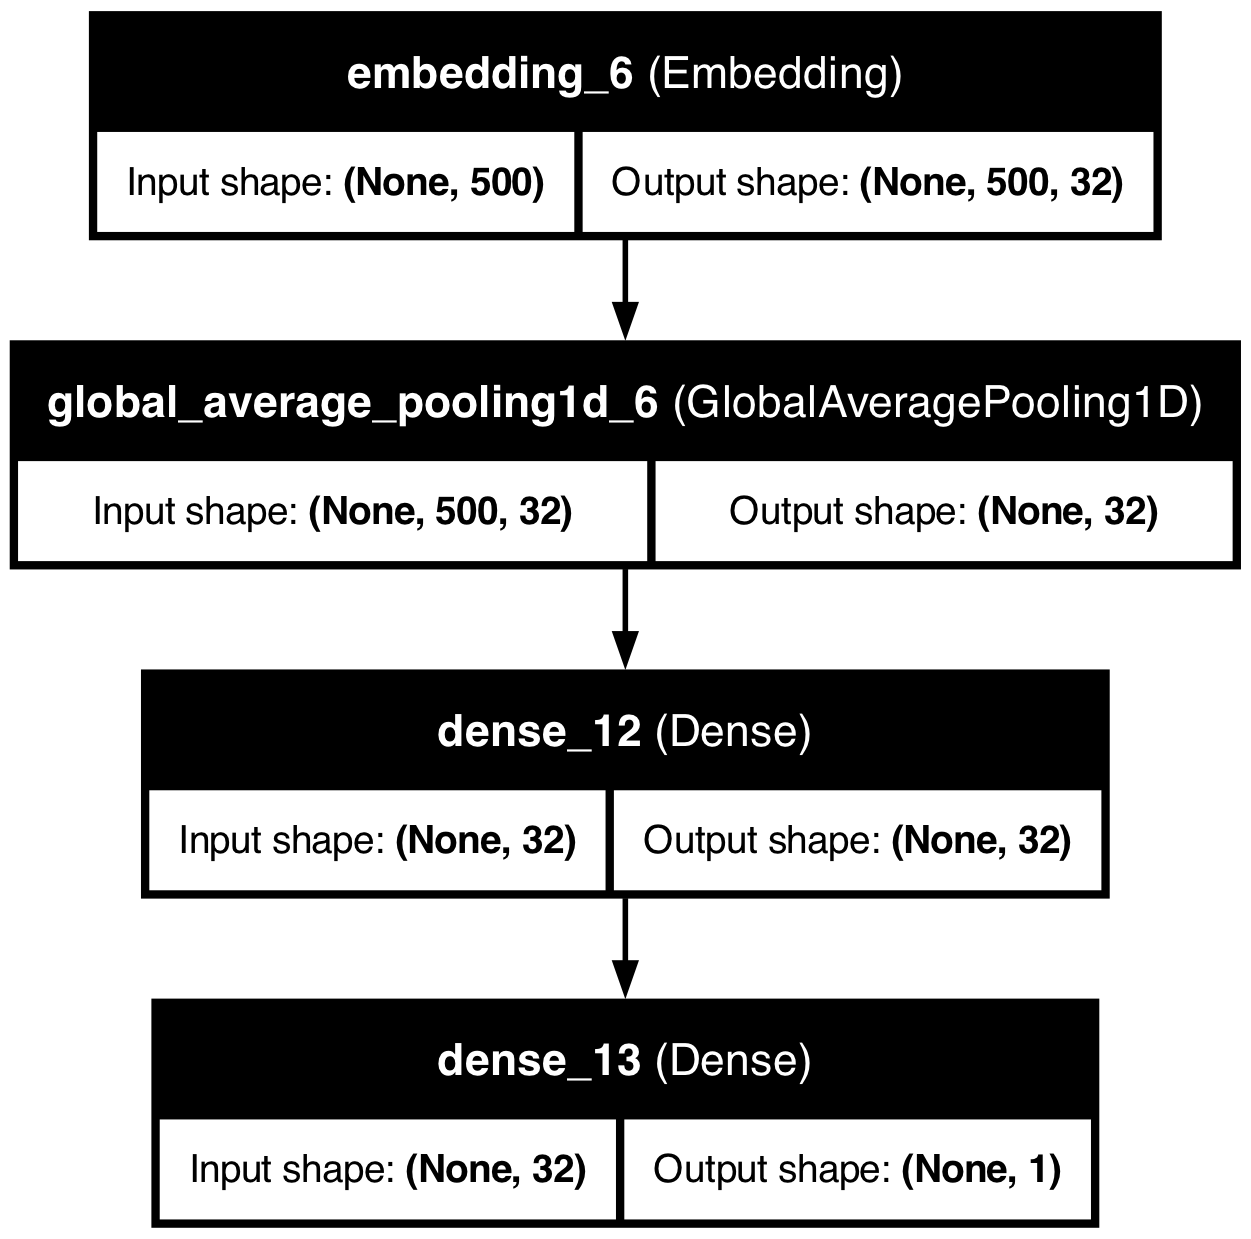

In [15]:
# TODO: print architecture summary
baseline.summary()

# TODO: save a DAG figure when Graphviz/pydot are available
DIAGRAM_FILE = "imdb_model.png"
if plot_model is not None:
    try:
        plot_model(
            baseline,  # swap for reg_model later if you prefer that diagram
            to_file=DIAGRAM_FILE,
            show_shapes=True,
            show_layer_names=True,
        )
        print(f"Wrote {DIAGRAM_FILE} — commit it to your GitHub repo")
        # Optional: display in notebook
        # from IPython.display import Image, display
        display(Image(DIAGRAM_FILE), width=100)
    except Exception as e:
        print("plot_model failed — use summary + hand diagram:", e)
else:
    print("plot_model unavailable — use model.summary() and a markdown/hand diagram")

## 3. Regularised model

Choose **exactly two** (or more if curious, but Moodle asks for two) of:

| Technique | Typical hook |
|-----------|----------------|
| L2 | `kernel_regularizer=regularizers.l2(...)` on a Dense layer |
| Dropout | `layers.Dropout(rate)` after a Dense / before the output |
| Early stopping | `callbacks.EarlyStopping(monitor="val_loss", patience=..., restore_best_weights=True)` |

Hints:
- Set boolean flags below so you can print which techniques you used
- `compile` again after building the stack
- Pass a **list of callbacks** into `fit` (empty list if you did not pick early stopping)
- Train long enough that early stopping might fire (e.g. more epochs than the baseline)
- Best val accuracy → Moodle `a3_best_val`; names → `a3_techniques`

In [16]:
USE_L2 = False          # set True if using L2
USE_DROPOUT = True     # set True if using dropout
USE_EARLY_STOP = True  # set True if using EarlyStopping

# Example L2 strength if USE_L2:
# l2_reg = regularizers.l2(1e-4)

reg_model = keras.Sequential([
    # TODO: Embedding + pooling as in baseline
    # TODO: Dense with optional kernel_regularizer=
    layers.Embedding(max_features, 32),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation="relu"),
])

if USE_DROPOUT:
    reg_model.add(layers.Dropout(0.3))
reg_model.add(layers.Dense(1, activation="sigmoid"))

# TODO: compile
reg_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cb = []
if USE_EARLY_STOP:
     cb.append(callbacks.EarlyStopping(
         monitor="val_loss",
         patience=2,
         restore_best_weights=True
    ))  # restore_best_weights=True is recommended (Week 5)

# TODO: fit → hist_reg
hist_reg = reg_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=512,
    validation_data=(x_val, y_val),
    callbacks=cb,
    verbose=1
)

best_val_acc = max(hist_reg.history["val_accuracy"])
techniques = []
if USE_L2:
    techniques.append("L2")
if USE_DROPOUT:
    techniques.append("dropout")
if USE_EARLY_STOP:
    techniques.append("early stopping")

print(f"Techniques (Moodle a3_techniques): {', '.join(techniques)}")
print(f"Best val accuracy (Moodle a3_best_val): {best_val_acc}")
assert len(techniques) >= 2, "Enable (at least) two techniques for full credit"

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5315 - loss: 0.6920 - val_accuracy: 0.5414 - val_loss: 0.6898
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5957 - loss: 0.6846 - val_accuracy: 0.5831 - val_loss: 0.6774
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6515 - loss: 0.6639 - val_accuracy: 0.6095 - val_loss: 0.6544
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6865 - loss: 0.6296 - val_accuracy: 0.6516 - val_loss: 0.6162
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7334 - loss: 0.5835 - val_accuracy: 0.7871 - val_loss: 0.5536
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7801 - loss: 0.5273 - val_accuracy: 0.8070 - val_loss: 0.5022
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8094 - loss: 0.4747 - val_accuracy: 0.8129 - val_loss: 0.4632
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8260 - loss: 0.4358 - val_accuracy: 0.8200 - v

## 4. Learning-rate schedule

Week 5 / Ch 7 callback: try **`ReduceLROnPlateau`** (shrink LR when `val_loss` stalls)
or a custom **`LearningRateScheduler`**.

Hints:
- Start from the baseline or your regularised architecture (`build_baseline()` is fine)
- Put the schedule callback in the `callbacks=[...]` list for `fit`
- After training, plot the learning-rate history if present (`hist.history.get("lr", [])` for ReduceLROnPlateau)
- Short markdown below: which schedule, why those hyperparameters, what you observed

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5561 - loss: 0.6905 - val_accuracy: 0.5435 - val_loss: 0.6873 - learning_rate: 0.0010
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6175 - loss: 0.6777 - val_accuracy: 0.6269 - val_loss: 0.6667 - learning_rate: 0.0010
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6851 - loss: 0.6487 - val_accuracy: 0.6444 - val_loss: 0.6339 - learning_rate: 0.0010
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7242 - loss: 0.6040 - val_accuracy: 0.6639 - val_loss: 0.5943 - learning_rate: 0.0010
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7409 - loss: 0.5556 - val_accuracy: 0.7707 - val_loss: 0.5306 - learning_rate: 0.0010
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8050 - loss: 0.4957 - val_accuracy: 0.8192 - val_loss: 0.4794 - learning_rate: 0.0010
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8359 - loss: 0.4458 - val_acc

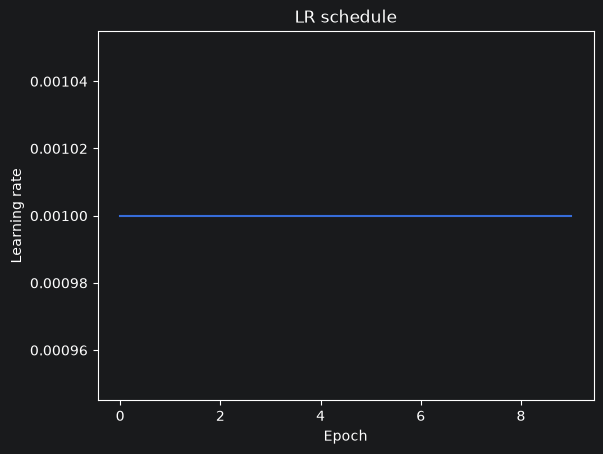

In [21]:
lr_model = build_baseline()  # or rebuild your regularised architecture

# TODO: choose one schedule callback, e.g.
lr_cb = callbacks.ReduceLROnPlateau(
   monitor="val_loss", factor=0.8, patience=1, min_lr=1e-6, verbose=1
 )

hist_lr = lr_model.fit(
     x_train, y_train,
     epochs=10,
     batch_size=512,
     validation_data=(x_val, y_val),
     callbacks=[lr_cb],  # may combine with EarlyStopping
     verbose=1,
 )

# TODO: plot LR vs epoch when the history key exists
lrs = hist_lr.history.get("learning_rate", hist_lr.history.get("lr", []))

if len(lrs) > 0:
    plt.plot(lrs)
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.title("LR schedule")
    plt.show()
else:
    print("Learning rate history was not recorded.")

**LR experiment notes** (a few sentences):

- Schedule used:I used ReduceLROnPlateau to reduce the learning rate when validation loss stopped improving.
- Observed effect on val curves / final accuracy:The schedule helped the model make smaller updates after progress slowed, which made training more stable.
    Baseline model: 0.8525
	Regularised model: 0.8546
	Learning-rate schedule model: 0.8578
- Would you keep this schedule for a real project? Yes, because it automatically adjusts the learning rate and can help improve validation performance without much extra code.

## 5. Save best model

Hints (Ch 7):
- Pick one of baseline / regularised / LR-tuned
- `best_model.save("something.keras")` — full architecture + weights
- `keras.models.load_model(...)` and `evaluate` on **test** once (do not retune on test)
- Commit the `.keras` file and the diagram PNG to your GitHub repo
- Filename → Moodle `a3_model_file`

In [22]:
MODEL_FILE = "imdb_sentiment_best.keras"  # Moodle a3_model_file

# TODO: choose the model object you consider best
best_model = lr_model #reg_model  or baseline or lr_model

# TODO: save
best_model.save(MODEL_FILE)

# TODO: reload and evaluate on the test set once
loaded = keras.models.load_model(MODEL_FILE)
_, test_acc = loaded.evaluate(x_test, y_test, verbose=0)

print(f"Saved model filename (Moodle a3_model_file): {MODEL_FILE}")
print(f"Test accuracy of saved model: {test_acc:.4f}")

Saved model filename (Moodle a3_model_file): imdb_sentiment_best.keras
Test accuracy of saved model: 0.8529


## 6. What did you learn?

Write ~200 words in the cell below (or paste the same text into Moodle if asked).
Cover: baseline vs regularised result, whether a technique hurt or helped, LR schedule takeaway, and one thing you would try next.

In this assignment, I learned how regularisation and learning-rate scheduling can affect model performance on the IMDB sentiment classification task. My baseline model achieved a validation accuracy of 0.8525. After applying dropout and early stopping, the regularised model improved slightly to 0.8546. This suggests that a moderate dropout rate can help reduce overfitting without removing too much useful information from the model.

The learning-rate schedule model achieved the best validation accuracy of 0.8578, so I selected it as my best model. I used ReduceLROnPlateau, which reduced the learning rate when the validation loss stopped improving. This helped the model make smaller updates later in training and gave the best validation result. After saving and reloading the best model, it achieved a test accuracy of 0.8529, which was close to the validation accuracy.

I also found that regularisation and learning-rate scheduling do not automatically improve a model. If the dropout rate or learning-rate schedule parameters are not tuned well, the result may be worse than the baseline. In addition, random weight initialisation, shuffled batches, and dropout can affect the final accuracy, so I fixed the random seed to make the results more reproducible. For a future experiment, I would try combining dropout, early stopping, and ReduceLROnPlateau in one model.
